In [2]:
from facenet_pytorch import MTCNN, InceptionResnetV1, fixed_image_standardization, training
import torch
from torch.utils.data import DataLoader, SubsetRandomSampler
from torch import optim
from torch.optim.lr_scheduler import MultiStepLR
from torch.utils.tensorboard import SummaryWriter
from torchvision import datasets, transforms
import numpy as np
import os
import shutil

### Prepare the data

In [4]:
training_data_path = '/home/hbvision/mirsaid/smart-office/data/images'
extracttion_path = '/home/hbvision/mirsaid/smart-office/data/images'

os.makedirs(training_data_path, exist_ok=True)

for file in os.listdir(extracttion_path):
    class_name = file.split('.')[0].split('_')[0]
    os.makedirs(f'{training_data_path}/{class_name}', exist_ok=True)
    # Copy image to training data with real name as label
    shutil.copy(f'{extracttion_path}/{file}', f'{training_data_path}/{class_name}/{file}')

In [ ]:
data_dir = '/home/hbvision/mirsaid/smart-office/data/images'

batch_size = 32
epochs = 100
workers = 0 if os.name == 'nt' else 8

In [6]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Running on device: {}'.format(device))

Running on device: cuda:0


In [23]:
mtcnn = MTCNN(
    image_size=160, margin=0, min_face_size=20,
    thresholds=[0.6, 0.7, 0.7], factor=0.709, post_process=True,
    device=device
)

In [11]:
dataset = datasets.ImageFolder(data_dir, transform=transforms.Resize((512, 512)))
dataset.samples = [
    (p, p.replace(data_dir, data_dir + '_cropped'))
        for p, _ in dataset.samples
]
        
loader = DataLoader(
    dataset,
    num_workers=workers,
    batch_size=batch_size,
    collate_fn=training.collate_pil
)

for i, (x, y) in enumerate(loader):
    mtcnn(x, save_path=y)
    print('\rBatch {} of {}'.format(i + 1, len(loader)), end='')
    
# Remove mtcnn to reduce GPU memory usage
del mtcnn

Batch 2 of 2

In [21]:
print(f'Number of classes: {len(dataset.class_to_idx)}')

Number of classes: 31


In [13]:
resnet = InceptionResnetV1(
    classify=True,
    pretrained='vggface2',
    num_classes=len(dataset.class_to_idx)
).to(device)

In [14]:
optimizer = optim.Adam(resnet.parameters(), lr=0.001)
scheduler = MultiStepLR(optimizer, [5, 10])

trans = transforms.Compose([
    np.float32,
    transforms.ToTensor(),
    fixed_image_standardization
])
dataset = datasets.ImageFolder(data_dir + '_cropped', transform=trans)
img_inds = np.arange(len(dataset))
np.random.shuffle(img_inds)
train_inds = img_inds[:int(0.8 * len(img_inds))]
val_inds = img_inds[int(0.8 * len(img_inds)):]

train_loader = DataLoader(
    dataset,
    num_workers=workers,
    batch_size=batch_size,
    sampler=SubsetRandomSampler(train_inds)
)
val_loader = DataLoader(
    dataset,
    num_workers=workers,
    batch_size=batch_size,
    sampler=SubsetRandomSampler(val_inds)
)

In [15]:
loss_fn = torch.nn.CrossEntropyLoss()
metrics = {
    'fps': training.BatchTimer(),
    'acc': training.accuracy
}

In [ ]:
writer = SummaryWriter()
writer.iteration, writer.interval = 0, 10

print('\n\nInitial')
print('-' * 10)
resnet.eval()
training.pass_epoch(
    resnet, loss_fn, val_loader,
    batch_metrics=metrics, show_running=True, device=device,
    writer=writer
)

for epoch in range(epochs):
    print('\nEpoch {}/{}'.format(epoch + 1, epochs))
    print('-' * 10)

    resnet.train()
    training.pass_epoch(
        resnet, loss_fn, train_loader, optimizer, scheduler,
        batch_metrics=metrics, show_running=True, device=device,
        writer=writer
    )

    resnet.eval()
    training.pass_epoch(
        resnet, loss_fn, val_loader,
        batch_metrics=metrics, show_running=True, device=device,
        writer=writer
    )

writer.close()



Initial
----------
Valid |     1/1    | loss:    3.3314 | fps:    0.1664 | acc:    0.1250   

Epoch 1/10
----------
Train |     1/1    | loss:    0.0345 | fps:  171.5336 | acc:    1.0000   
Valid |     1/1    | loss:    3.3303 | fps:   41.4959 | acc:    0.1250   

Epoch 2/10
----------
Train |     1/1    | loss:    0.0306 | fps:  178.2977 | acc:    1.0000   
Valid |     1/1    | loss:    3.3346 | fps:   48.3755 | acc:    0.1250   

Epoch 3/10
----------
Train |     1/1    | loss:    0.0302 | fps:  179.6396 | acc:    1.0000   
Valid |     1/1    | loss:    3.3463 | fps:   49.9946 | acc:    0.1250   

Epoch 4/10
----------
Train |     1/1    | loss:    0.0298 | fps:  177.9258 | acc:    1.0000   
Valid |     1/1    | loss:    3.3551 | fps:   42.4158 | acc:    0.1250   

Epoch 5/10
----------
Train |     1/1    | loss:    0.0291 | fps:  167.9159 | acc:    1.0000   
Valid |     1/1    | loss:    3.3646 | fps:   47.1696 | acc:    0.1250   

Epoch 6/10
----------
Train |     1/1    | loss: 

In [20]:
## Save the model
model_path = '/home/hbvision/mirsaid/smart-office/data/model'
os.makedirs(model_path, exist_ok=True)
torch.save(resnet.state_dict(), f'{model_path}/model.pt')


In [62]:
from PIL import Image
import matplotlib.pyplot as plt
from ultralytics import YOLO
import cv2

one_test_face = '/home/hbvision/mirsaid/smart-office/body_crops/Mirsaid_20250210-144931.jpg'
img = cv2.imread(one_test_face)

face_detector = YOLO('/home/hbvision/mirsaid/smart-office/yolov8m-face.pt')
faces = face_detector(img)

for face in faces:
    for box in face.boxes:
        x1, y1, x2, y2 =  map(int, box.xyxy[0])
        img_cropped = img[y1:y2, x1:x2]

        resized_face = cv2.resize(img_cropped, (160, 160))
        resized_face = cv2.cvtColor(resized_face, cv2.COLOR_BGR2RGB)

        face_tensor = (
            torch.tensor(resized_face).permute(2, 0, 1).float().to(device)
            / 255.0
        )
        face_tensor = face_tensor.unsqueeze(0)

        # Classify the face using our model
        result = resnet(face_tensor)


0: 960x576 1 face, 27.0ms
Speed: 1.6ms preprocess, 27.0ms inference, 0.5ms postprocess per image at shape (1, 3, 960, 576)


In [63]:
result.argmax(dim=1).item()

20

In [65]:
dataset.class_to_idx

{'Abdulhamid': 0,
 'Abdulloh': 1,
 'Arsen': 2,
 'Asadbek': 3,
 'Azamat': 4,
 'Bahodir': 5,
 'BahodirNematjonov': 6,
 'Batkhuu': 7,
 'Dilshod': 8,
 'Diyorjon': 9,
 'Elyor': 10,
 'Gofurjon': 11,
 'Humoyun': 12,
 'Javokhir': 13,
 'Jumabek': 14,
 'Kamoliddin': 15,
 'Madamin': 16,
 'Maruf': 17,
 'Mirjalol': 18,
 'Mironshoh': 19,
 'Mirsaid': 20,
 'Murtazo': 21,
 'Murtazokhon': 22,
 'Otabek': 23,
 'Oybek': 24,
 'Saidazizkhon': 25,
 'Sarvar': 26,
 'Shohruh': 27,
 'Sokhibjon': 28,
 'Tilov': 29,
 'Uktam': 30}

Intersects: True


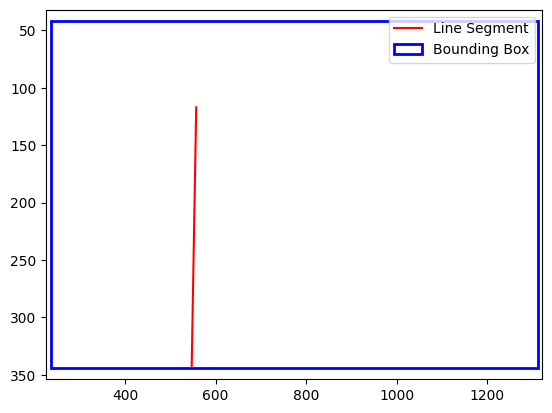

In [3]:
import matplotlib.pyplot as plt

def bbox_intersects_line(bbox, line_points, epsilon=0.00001):
    x_min, y_min, x_max, y_max = bbox[2], bbox[3], bbox[0], bbox[1]  # Ensure bbox format

    x1, y1 = line_points[0]
    x2, y2 = line_points[1]

    def is_inside(x, y):
        return x_min - epsilon <= x <= x_max + epsilon and y_min - epsilon <= y <= y_max + epsilon

    def line_intersects_rect():
        if is_inside(x1, y1) or is_inside(x2, y2):
            return True  # One endpoint is inside the bbox
        
        bbox_edges = [
            ((x_min, y_min), (x_min, y_max)),  # Left edge
            ((x_min, y_max), (x_max, y_max)),  # Top edge
            ((x_max, y_max), (x_max, y_min)),  # Right edge
            ((x_max, y_min), (x_min, y_min))   # Bottom edge
        ]
        
        for edge in bbox_edges:
            if line_intersects_line(edge[0], edge[1], (x1, y1), (x2, y2), epsilon):
                return True
        
        return False

    def line_intersects_line(p1, p2, q1, q2, eps):
        def ccw(a, b, c):
            return (c[1] - a[1]) * (b[0] - a[0]) > (b[1] - a[1]) * (c[0] - a[0])

        def distance(p1, p2):
            return ((p1[0] - p2[0]) ** 2 + (p1[1] - p2[1]) ** 2) ** 0.5

        if ccw(p1, q1, q2) != ccw(p2, q1, q2) and ccw(p1, p2, q1) != ccw(p1, p2, q2):
            return True

        # Check if the line endpoint is very close to the bbox edge (floating point tolerance)
        return any(distance(p, q) < eps for p in [p1, p2] for q in [q1, q2])

    return line_intersects_rect()

# Example usage
bbox = [1312, 344, 235, 42]
line_points = [[557, 117], [547, 343]]

# Check intersection
intersects = bbox_intersects_line(bbox, line_points)
print("Intersects:", intersects)

# Visualization
fig, ax = plt.subplots()
ax.plot([line_points[0][0], line_points[1][0]], [line_points[0][1], line_points[1][1]], 'r-', label="Line Segment")
rect = plt.Rectangle((bbox[2], bbox[3]), bbox[0] - bbox[2], bbox[1] - bbox[3], linewidth=2, edgecolor='b', facecolor='none', label="Bounding Box")
ax.add_patch(rect)
ax.set_xlim(min(bbox[2], line_points[0][0], line_points[1][0]) - 10, max(bbox[0], line_points[0][0], line_points[1][0]) + 10)
ax.set_ylim(min(bbox[3], line_points[0][1], line_points[1][1]) - 10, max(bbox[1], line_points[0][1], line_points[1][1]) + 10)
ax.invert_yaxis()
ax.legend()
plt.show()


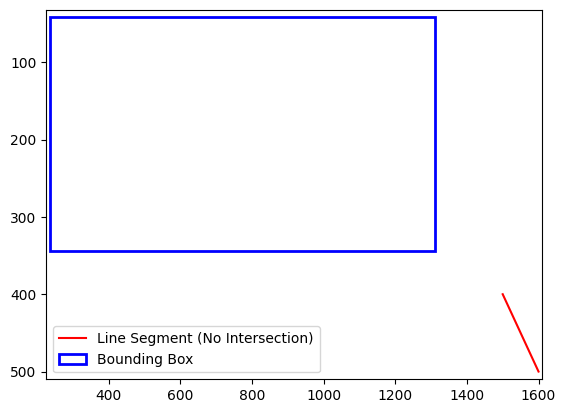

In [5]:
# Example of non-intersecting case
bbox = [1312, 344, 235, 42]
line_points = [(1500, 400), (1600, 500)]  # Line is far away from the bbox

# Check intersection
intersects = bbox_intersects_line(bbox, line_points)

# Visualization
fig, ax = plt.subplots()
ax.plot([line_points[0][0], line_points[1][0]], [line_points[0][1], line_points[1][1]], 'r-', label="Line Segment (No Intersection)")
rect = plt.Rectangle((bbox[2], bbox[3]), bbox[0] - bbox[2], bbox[1] - bbox[3], linewidth=2, edgecolor='b', facecolor='none', label="Bounding Box")
ax.add_patch(rect)
ax.set_xlim(min(bbox[2], line_points[0][0], line_points[1][0]) - 10, max(bbox[0], line_points[0][0], line_points[1][0]) + 10)
ax.set_ylim(min(bbox[3], line_points[0][1], line_points[1][1]) - 10, max(bbox[1], line_points[0][1], line_points[1][1]) + 10)
ax.invert_yaxis()
ax.legend()
plt.show()

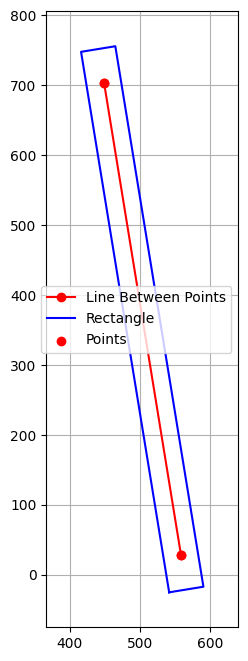

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Given two points
point1 = np.array([559, 28])  # [x1, y1]
point2 = np.array([449, 703])  # [x2, y2]

# Define width and height of the rectangle
w = 100  # width
h = 50   # height

# Calculate the direction vector from point1 to point2
direction = point2 - point1
length = np.linalg.norm(direction)

# Normalize the direction vector
direction_normalized = direction / length

# Perpendicular direction (rotate 90 degrees counter-clockwise)
perpendicular = np.array([-direction_normalized[1], direction_normalized[0]])

# Create the rectangle by shifting points along the perpendicular direction
half_w = w / 2
half_h = h / 2

# Calculate the four corners of the rectangle
corner1 = point1 + perpendicular * half_h - direction_normalized * half_w
corner2 = point1 - perpendicular * half_h - direction_normalized * half_w
corner3 = point2 - perpendicular * half_h + direction_normalized * half_w
corner4 = point2 + perpendicular * half_h + direction_normalized * half_w

# Convert corners to integer for plotting
corners = np.array([corner1, corner2, corner3, corner4, corner1]).astype(int)

# Plotting the rectangle and the original points
plt.figure(figsize=(8, 8))
plt.plot([point1[0], point2[0]], [point1[1], point2[1]], 'ro-', label="Line Between Points")
plt.plot(corners[:, 0], corners[:, 1], 'b-', label="Rectangle")
plt.scatter([point1[0], point2[0]], [point1[1], point2[1]], color='red', label="Points")
plt.xlim(min(corners[:, 0]) - 50, max(corners[:, 0]) + 50)
plt.ylim(min(corners[:, 1]) - 50, max(corners[:, 1]) + 50)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.grid(True)
plt.show()
